Import ROOT:

In [1]:
import ROOT
import numpy as np

Create and fill a histogram with 5000 normally distributed variables:

In [2]:
h1d_gaus = ROOT.TH1D(name="h1d_gaus", title = "My histo", nbinsx = 100, xlow = -5, xup = 5)
h1d_gaus.FillRandom("gaus", ntimes = 5000)

Draw a histogram:

In [3]:
%jsroot on
# JavaScript ROOT; Provides interactive graphics

c = ROOT.TCanvas() # create a canvas
h1d_gaus.SetLineColor(ROOT.kBlue)
h1d_gaus.SetFillColor(ROOT.kBlue)
h1d_gaus.GetXaxis().SetTitle("value")
h1d_gaus.GetYaxis().SetTitle("count")
h1d_gaus.SetTitle("My histo with latex: p_{t}, #eta, #phi")

h1d_gaus.Draw() # draw the histogram on the canvas
c.Draw() # draw the canvas on the screen

The Unified Histogram Interface (UHI):
 - provides a pythonic interface for working with histograms
 - allows histogram manipulation using Numpy-like syntax

In [4]:
from ROOT.uhi import underflow, overflow
import matplotlib.pyplot as plt
import mplhep as hep # matplotlib wrapper used in high energy physics

In [6]:
# Look at difference between Fill and SetBinContent

h_fill_set = ROOT.TH1D("h","Fill vs SetBinContent", 3, 0, 3)
h_fill_set.Fill(2.5) # adds a data point with value 2.5 to histogram

print("After Fill(2.5):", h_fill_set.values())

h_fill_set.Reset()
h_fill_set.SetBinContent(1, 2.5) # manually sets the value of bin 1 to 2.5
print("\nAfter SetBinContent(1, 2.5):", h_fill_set.values())

After Fill(2.5): [0. 0. 1.]

After SetBinContent(1, 2.5): [2.5 0.  0. ]


Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


In [7]:
h1d_uhi_basic = ROOT.TH1D(name="h1d_uhi_basic", title="My UHI histo", nbinsx=10, xlow=0, xup=1)

# Setting the histogram content using UHI-style indexing syntax
h1d_uhi_basic[...] = np.linspace(0, 11, 12)  # set with 0..11, including under/overflow

"""
# equivalent native ROOT-style loop for setting bin contents
values = np.linspace(0, 11, 12)
for i in range(0, h1d_uhi_basic.GetNbinsX() + 2):  # +2 to include under/overflow
    h1d_uhi_basic.SetBinContent(i, values[i])
"""

print(f"Bin contents: {h1d_uhi_basic.values()}")
print(f"Underflow: {h1d_uhi_basic[underflow]}, Overflow: {h1d_uhi_basic[overflow]}")

Bin contents: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Underflow: 0.0, Overflow: 11.0


/opt/conda/lib/python3.13/site-packages/mplhep/_utils.py:437: UserWarning: Integer weights indicate poissonian data. Will calculate Garwood interval if ``scipy`` is installed. Otherwise errors will be set to ``sqrt(w2)``.
  _plottable.errors(assume_variances_equal_values=True)


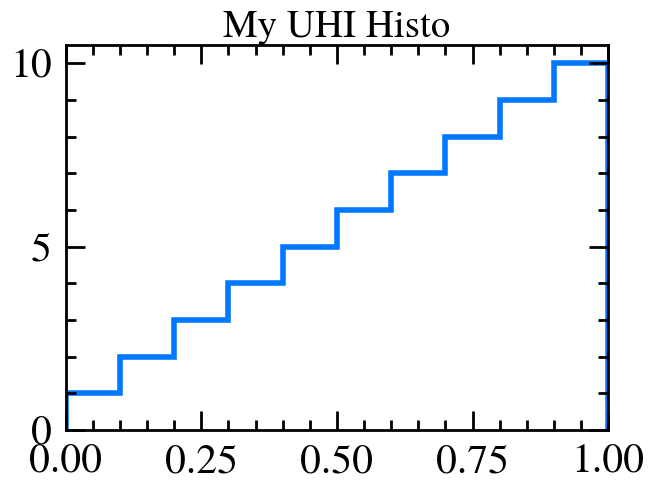

In [8]:
hep.style.use("LHCb2")  # set the style to LHCb2

plt.figure(figsize=(7,5))
hep.histplot(
    h1d_uhi_basic,
    yerr=False,
    linewidth=4,
)
plt.title("My UHI Histo")
plt.show()

Exercise: Using NumPy’s np.histogram, fill a histogram that matches the distribution of h1d_gaus above, and plot it using mplhep.

/opt/conda/lib/python3.13/site-packages/mplhep/_utils.py:437: UserWarning: Integer weights indicate poissonian data. Will calculate Garwood interval if ``scipy`` is installed. Otherwise errors will be set to ``sqrt(w2)``.
  _plottable.errors(assume_variances_equal_values=True)


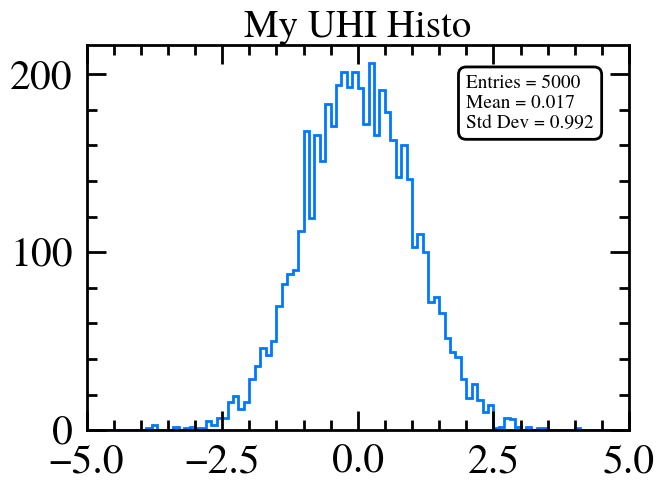

Warning in <TROOT::Append>: Replacing existing TH1: h1d_uhi_gauss (Potential memory leak).


In [10]:
# Solution
h1d_uhi_gauss = ROOT.TH1D(name="h1d_uhi_gauss", title="My UHI histo", nbinsx=100, xlow=-5, xup=5)
h1d_uhi_gauss[...] = np.histogram(np.random.normal(size=5000), bins=100, range=(-5,5))[0]
# or call h1d_uhi_gauss.Fill(np.random.normal(size=5000))

entries = h1d_uhi_gauss.GetEntries()
mean = h1d_uhi_gauss.GetMean()
std = h1d_uhi_gauss.GetStdDev()

plt.figure(figsize=(7,5))
hep.histplot(h1d_uhi_gauss, linewidth=2, yerr=False)
plt.title("My UHI Histo")

stats_text = (
    f"Entries = {entries:.0f}\n"
    f"Mean = {mean:.3f}\n"
    f"Std Dev = {std:.3f}"
)

plt.text(
    2, 170, stats_text,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white")
)

plt.show()

MODELLING AND FITTING DATA

Root Functions:

In [11]:
f2 = ROOT.TF2("f2", "sin(x*x - y*y)", xmin=-2, xmax=2, ymin=-2, ymax=2)


c = ROOT.TCanvas()
f2.Draw("surf1") # to get a surface instead of the default contour plot
c.Draw()



Fitting a Histogram

In [12]:
# Define a gaussian function

def gaussian(x: np.ndarray, pars: np.ndarray) -> float:    
    return pars[0] * np.exp(-np.power(x[0] - pars[1], 2) / 2) / np.sqrt(2 * np.pi)

# Define the fit function

fitFunc = ROOT.TF1("fitFunc", gaussian, xmin=-5, xmax=5, npar=2)

# Fit the histogram

res = h1d_gaus.Fit(fitFunc, "S") # the "S" option makes the function return a fit result object

# Draw the histogram (automatically draws the fit)

c2 = ROOT.TCanvas()
h1d_gaus.Draw()
c2.Draw()




****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      57.2302
NDf                       =           67
Edm                       =  1.34911e-09
NCalls                    =           44
p0                        =      494.933   +/-   7.03982     
p1                        =    0.0173689   +/-   0.0142894   


In [13]:
# Note that this can also be done with built-in Gaussian function: 

res = h1d_gaus.Fit("gaus", "S")

c3 = ROOT.TCanvas()
h1d_gaus.Draw()
c3.Draw()


****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      57.2152
NDf                       =           66
Edm                       =  9.31601e-06
NCalls                    =           55
Constant                  =      197.704   +/-   3.46748     
Mean                      =    0.0172556   +/-   0.014353    
Sigma                     =      0.99873   +/-   0.0103909    	 (limited)


VISUALISING AND COMBINING RESULTS

ROOT Graphs

In [ ]:
# Scatter Plot 

x = np.arange(-20, 21, dtype=float)
y = -x*x
g = ROOT.TGraph(n=x.size, x=x, y=y)

c4 = ROOT.TCanvas()
g.SetMarkerStyle(7)
g.SetLineColor(ROOT.kBlue)
g.SetTitle("My graph")
g.Draw()
c4.Draw()


In [15]:
# Bar Plot

c5 = ROOT.TCanvas()
g.SetTitle("My graph")
g.SetFillColor(ROOT.kOrange + 1) # base colors can be tweaked by adding/subtracting values to them 
g.Draw("AB1")
c5.Draw()


Plot Example: Histogram Stack

In [16]:
f1 = ROOT.TF1("f1", "gaus", -4.0, 4.0)

histos = [ROOT.TH1D(f"h{i}", "x", 64, -4.0, 4.0) for i in range(3)]

hs = ROOT.THStack("hs","")
hs.SetTitle(";x;Events")

colors = [46, 30, 38]
        
for i in range(len(histos)):
    h = histos[i]
    f1.SetParameters(1.0, i - 1, 1.0)
    h.FillRandom("f1", 100000)
    h.SetFillColor(colors[i])
    hs.Add(h)

c6 = ROOT.TCanvas()
hs.Draw()
c6.Draw()

Plot Example: Efficiency Curves

In [17]:
h_pass = ROOT.TH1D("h_pass", "My histogram", 50, 0, 100.0)
h_total = ROOT.TH1D("h_total", "My histogram", 50, 0, 100.0)

f_gaus = ROOT.TF1("f_gaus", "gaus", 0, 100.0)

f_gaus.SetParameters(1.0, 56.0, 20.0)
h_pass.FillRandom("f_gaus", 40000)
h_pass.SetLineColor(ROOT.kRed)
f_gaus.SetParameters(1.0, 50.0, 20.0)
h_total.FillRandom("f_gaus", 100000)

In [18]:
teff = ROOT.TEfficiency(h_pass,h_total)

c7 = ROOT.TCanvas("rf101_basics", "rf101_basics", 800, 400)
c7.Divide(2)
c7.cd(1)
h_total.Draw()
h_pass.Draw("SAME")
c7.cd(2)
teff.Draw()
c7.Draw()

